In [1]:
import sympy as sp
import numpy as np

In [2]:
x, y, z = sp.symbols('x, y, z')

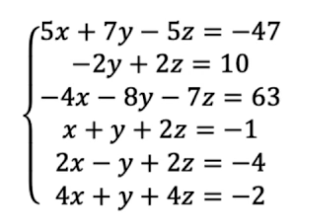

In [3]:
mse = 1/6 * (
    (5*x+7*y-5*z + 47)**2 +
    (-2*y +2*z - 10)**2 +
    (-4*x-8*y-7*z - 63)**2 +
    (x+y+2*z + 1)**2 +
    (2*x-y+2*z + 4)**2 +
    (4*x+y+4*z + 2)** 2
)

mse

0.166666666666667*(-2*y + 2*z - 10)**2 + 0.166666666666667*(-4*x - 8*y - 7*z - 63)**2 + 0.166666666666667*(x + y + 2*z + 1)**2 + 0.166666666666667*(2*x - y + 2*z + 4)**2 + 0.166666666666667*(4*x + y + 4*z + 2)**2 + 0.166666666666667*(5*x + 7*y - 5*z + 47)**2

# gradient descent

In [4]:
# Вычислим производные для MSE по x, y, z

mse_x = sp.diff(mse, x)
mse_y = sp.diff(mse, y)
mse_z = sp.diff(mse, z)

In [5]:
# зададим начальные точки координат для градиентного спуска

initial_point = [0, 0, 0]

In [6]:
# вычислим MSE для начальных координат

mse.subs({
    x: initial_point[0],
    y: initial_point[1],
    z: initial_point[2]
})

1049.83333333333

In [7]:
step = 0.01
n_iter = 50
mse_history = []
point = initial_point

In [8]:
for i in range(1, n_iter+1):
    
    mse_result = mse.subs({x: point[0], y: point[1], z: point[2]})

    mse_history.append(mse_result)
    
    gradient = np.array([
        mse_x.subs({x: point[0], y: point[1], z: point[2]}),
        mse_y.subs({x: point[0], y: point[1], z: point[2]}),
        mse_z.subs({x: point[0], y: point[1], z: point[2]})
        
    ])

    point = point - step * gradient
    if (i == 1) or (i % 10 == 0):
        print(f'iter - {i}, mse = {mse_result}')
    

iter - 1, mse = 1049.83333333333
iter - 10, mse = 50.9155148661358
iter - 20, mse = 41.9372197021397
iter - 30, mse = 38.5754571160574
iter - 40, mse = 37.3015671774364
iter - 50, mse = 36.8188336146868


# least squares solution

In [9]:
X = np.array([[5,7,-5], [0,-2,2], [-4,-8,-7], [1,1,2], [2,-1,2], [4,1,4]])
b = np.array([-47, 10, 63, -1, -4, -2])

beta = np.linalg.lstsq(X, b, rcond=None)[0]

print(f'MSE = {mse.subs({x: beta[0], y: beta[1], z: beta[2]})}')

MSE = 36.5242879107706


# Псевдообратная: X⁺ = (X^T X)^{-1} X^T

In [10]:
X_transpose = X.T

psev_solve = (np.linalg.inv(X_transpose @ X) @ X_transpose) @ b

In [11]:
mse.subs({x: psev_solve[0], y: psev_solve[1], z: psev_solve[2]})

36.5242879107706

# Сравнение всех моделей

In [12]:
# gradient_descent

x, y, z = sp.symbols('x y z')

mse = 1/6 * (
    (5*x + 7*y - 5*z + 47)**2 +
    (-2*y + 2*z - 10)**2 +
    (-4*x - 8*y - 7*z - 63)**2 +
    (x + y + 2*z + 1)**2 +
    (2*x - y + 2*z + 4)**2 +
    (4*x + y + 4*z + 2)**2
)

def gradient_descent(mse, step=0.01, n_iter=50):
    mse_x = sp.diff(mse, x)
    mse_y = sp.diff(mse, y)
    mse_z = sp.diff(mse, z)
    
    point = np.array([0.0, 0.0, 0.0])
    
    for i in range(n_iter):
        # Градиент в текущей точке
        grad = np.array([
            float(mse_x.subs({x: point[0], y: point[1], z: point[2]})),
            float(mse_y.subs({x: point[0], y: point[1], z: point[2]})),
            float(mse_z.subs({x: point[0], y: point[1], z: point[2]}))
        ])
        
        # Обновляем точку
        point = point - step * grad
    
    # Считаем MSE в конечной точке
    final_mse = float(mse.subs({x: point[0], y: point[1], z: point[2]}))
    
    return point, final_mse

In [14]:
# least squares solution

X = np.array([[5,7,-5], [0,-2,2], [-4,-8,-7], [1,1,2], [2,-1,2], [4,1,4]])
b = np.array([-47, 10, 63, -1, -4, -2])

def least_squatr_sol(X, b, mse_expr):

    beta = np.linalg.lstsq(X, b, rcond=None)[0]
    
    
    
    # Вычисляем MSE в этой точке
    mse_val = float(mse_expr.subs({x: beta[0], y: beta[1], z: beta[2]}))

    return beta, mse_val

In [22]:
# Pseudoinverse matrix 

def pseudoinverse_matrix(X, b):
    X_transpose = X.T
    psev_solve = (np.linalg.inv(X_transpose @ X) @ X_transpose) @ b
    psev_mse_result = mse.subs({x: psev_solve[0], y: psev_solve[1], z: psev_solve[2]})
    
    return psev_solve, psev_mse_result

In [24]:
import time

start = time.perf_counter()
print('Gradient Desent')
point_GD, MSE_result_final_GD = gradient_descent(mse, step=0.01, n_iter=50)
print(point, MSE_result_final)
end = time.perf_counter()
print(f"Время: {(end - start)*1000:.2f} мс")

print('\n')

start = time.perf_counter()
print('least squares solution')
point_LSQ, MSE_result_final_LSQ = least_squatr_sol(X, b, mse)
print(point_LSQ, MSE_result_final_LSQ )
end = time.perf_counter()
print(f"Время: {(end - start)*1000:.2f} мс")

print('\n')

start = time.perf_counter()
print('Pseudoinverse matrix ')
point_PSEUDOINV, MSE_result_final_PSEUDOINV = pseudoinverse_matrix(X, b)
print(point_PSEUDOINV, MSE_result_final_PSEUDOINV )
end = time.perf_counter()
print(f"Время: {(end - start)*1000:.2f} мс")

Gradient Desent
[-0.27572539 -6.8266603  -0.52171832] 36.79159486266701
Время: 85.28 мс


least squares solution
[ 6.09803768e-03 -7.00570714e+00 -5.59143148e-01] 36.52428791077059
Время: 4.78 мс


Pseudoinverse matrix 
[ 6.09803768e-03 -7.00570714e+00 -5.59143148e-01] 36.5242879107706
Время: 4.48 мс


# Вывод

Градиентный спуск показал самое долгое время выполнения и за 50 итераций не достиг точности, которую дают аналитические методы МНК

Это ожидаемо, так как градиентный спуск это итеративный алгоритм, который приближается к решению постепенно, тогда как МНК (через lstsq или псевдообратную матрицу) даёт точное решение за один шаг

Однако на больших объёмах данных градиентный спуск становится предпочтительнее, поскольку аналитические методы требуют обращения матрицы, что вычислительно затратно и может быть численно неустойчиво